<a href="https://colab.research.google.com/github/jahnavimidde/Deep_learning/blob/main/DL8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import keras
from keras import datasets
from keras.models import Model, Sequential
from keras.layers import Conv2D, MaxPooling2D
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

layer_outputs = [layer.output for layer in model.layers]
feature_model = Model(inputs=model.input, outputs=layer_outputs)

img = x_test[0]
img = np.expand_dims(img, axis=0)

feature_maps = feature_model.predict(img)

for i, fmap in enumerate(feature_maps):
    print("Layer", i+1, "Shape:", fmap.shape)

    num_filters = fmap.shape[-1]

    plt.figure(figsize=(10,5))

    for j in range(min(num_filters, 6)):
        plt.subplot(1,6,j+1)
        plt.imshow(fmap[0, :, :, j], cmap='viridis')
        plt.axis('off')

    plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AttributeError: The layer sequential has never been called and thus has no defined input.

In [ ]:
import keras
from keras import datasets
from keras.models import Model, Sequential
from keras.layers import Conv2D, MaxPooling2D, Input
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = Sequential()

model.add(Input(shape=(32,32,3)))   # ✅ important fix

model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

layer_outputs = [layer.output for layer in model.layers]
feature_model = Model(inputs=model.input, outputs=layer_outputs)

img = x_test[0]
img = np.expand_dims(img, axis=0)

feature_maps = feature_model.predict(img)

for i, fmap in enumerate(feature_maps):
    print("Layer", i+1, "Shape:", fmap.shape)

    num_filters = fmap.shape[-1]

    plt.figure(figsize=(10,5))

    for j in range(min(num_filters, 6)):
        plt.subplot(1,6,j+1)
        plt.imshow(fmap[0, :, :, j], cmap='viridis')
        plt.axis('off')

    plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


AttributeError: The layer sequential has never been called and thus has no defined input.

In [ ]:
import keras
from keras import datasets
from keras.models import Model, Sequential
from keras.layers import Conv2D, MaxPooling2D, Input
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = Sequential()

model.add(Input(shape=(32,32,3)))   # ✅ important fix

model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

layer_outputs = [layer.output for layer in model.layers]
model.predict(np.zeros((1,32,32,3)))
feature_model = Model(inputs=model.input, outputs=layer_outputs)

img = x_test[0]
img = np.expand_dims(img, axis=0)

feature_maps = feature_model.predict(img)

for i, fmap in enumerate(feature_maps):
    print("Layer", i+1, "Shape:", fmap.shape)

    num_filters = fmap.shape[-1]

    plt.figure(figsize=(10,5))

    for j in range(min(num_filters, 6)):
        plt.subplot(1,6,j+1)
        plt.imshow(fmap[0, :, :, j], cmap='viridis')
        plt.axis('off')

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


AttributeError: The layer sequential_1 has never been called and thus has no defined input.

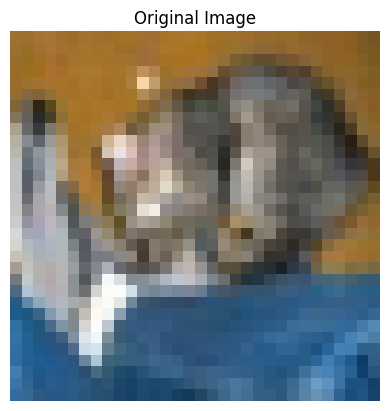

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
Layer 1 Shape: (1, 32, 32, 3)


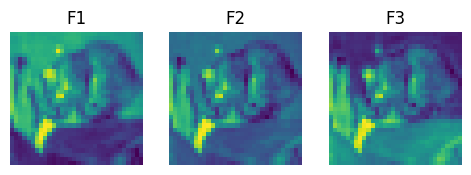

Layer 2 Shape: (1, 32, 32, 32)


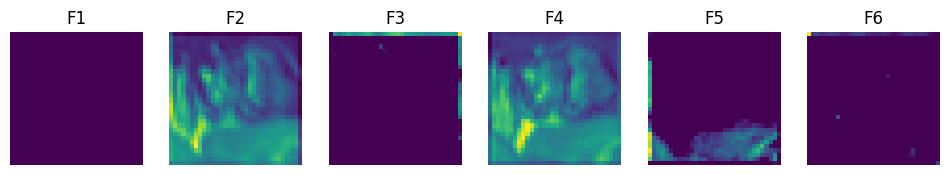

Layer 3 Shape: (1, 16, 16, 32)


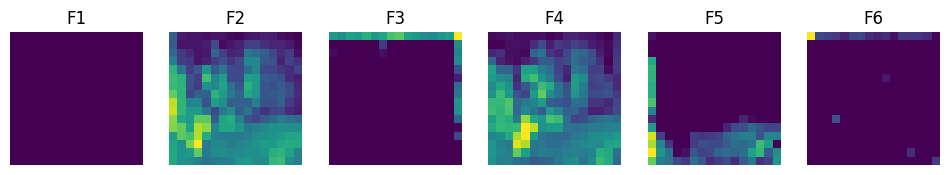

Layer 4 Shape: (1, 16, 16, 64)


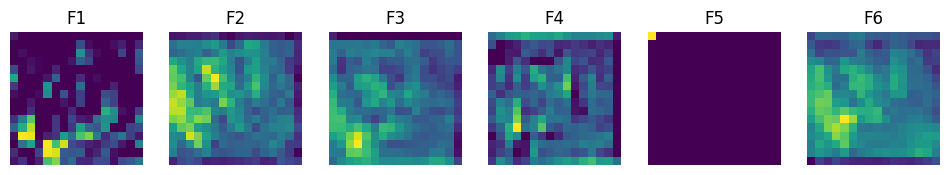

Layer 5 Shape: (1, 8, 8, 64)


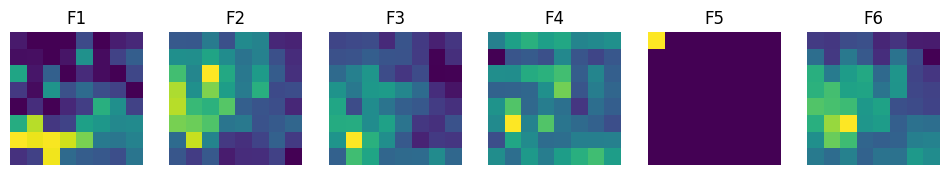

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Conv2D, MaxPooling2D, Input
import matplotlib.pyplot as plt
import numpy as np

# 🔷 Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# 🔷 Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# 🔷 Build Model using Functional API (no error)
input_layer = Input(shape=(32,32,3))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

model = Model(inputs=input_layer, outputs=x)

# 🔷 Create Feature Map Model (all layers)
layer_outputs = [layer.output for layer in model.layers]
feature_model = Model(inputs=model.input, outputs=layer_outputs)

# 🔷 Select Image
img = x_test[0]
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)

# 🔷 Get Feature Maps
feature_maps = feature_model.predict(img)

# 🔷 Plot Feature Maps
for i, fmap in enumerate(feature_maps):
    print("Layer", i+1, "Shape:", fmap.shape)

    num_filters = fmap.shape[-1]

    plt.figure(figsize=(12,5))

    for j in range(min(num_filters, 6)):
        plt.subplot(1,6,j+1)
        plt.imshow(fmap[0, :, :, j], cmap='viridis')
        plt.title(f"F{j+1}")
        plt.axis('off')

    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


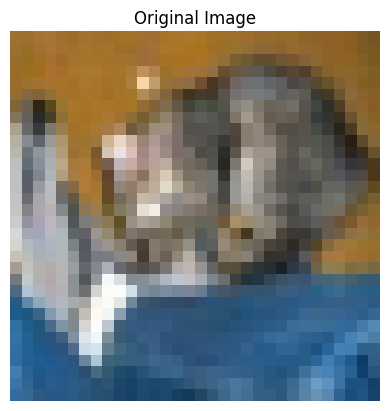

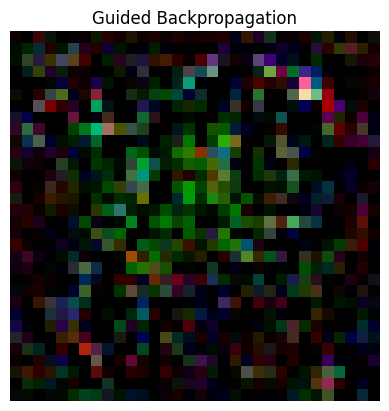

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

img = x_test[0]
label = y_test[0][0]

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)

img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img_tensor)

guided_grads = tf.maximum(grads, 0)
guided_grads = guided_grads.numpy()[0]

guided_grads -= guided_grads.min()
guided_grads /= guided_grads.max()

plt.imshow(guided_grads)
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()

In [ ]:
print("Predicted class:", class_idx.numpy())

Predicted class: 3


In [ ]:
print("Gradient shape:", grads.shape)

Gradient shape: (1, 32, 32, 3)
